In [102]:
"""
Train a Position LLM to generalize to Ojas's hand movements. Implement all
previous techniques like region tokenization on appendage vector components.

TODO:
    - hyperparameter tuning
"""

import torch
import wandb
from torch.nn import CrossEntropyLoss, MSELoss
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

from eeg.big_hand.position_llm import E2EPositionLLM, AppendageDataset

appendage_dataset: AppendageDataset = AppendageDataset()

appendage_dataloader = DataLoader(
    appendage_dataset, batch_size=32, shuffle=True)

print(
    f"Raw positions shape: {appendage_dataset.train_data.shape}, expected: (2, T, 63)"
)
print(
    f"Appendage data shape: {appendage_dataset.app_data.shape}, expected: (T, 12)")
print(
    f"Region tokens shape: {appendage_dataset.region_tokens.shape}, expected: (T)")

warmup_steps = 4000
base_lr = 5e-5


def lr_lambda(step):
    if step == 0:
        step = 1  # avoid div by zero
    if step < warmup_steps:
        return step / warmup_steps
    else:
        return (warmup_steps**0.5) / (step**0.5)


device = "cuda"
epochs = 10000
model = E2EPositionLLM()  # end to end position llm
model.load_state_dict(torch.load("/var/log/thavamount/eeg_ckpts/checkpoint10000.pth", map_location="cpu")["model"])
optimizer = AdamW(model.parameters(), lr=base_lr, betas=[0.9, 0.98], eps=1e-9)
scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
class_loss_fn = CrossEntropyLoss()
appendage_loss_fn = MSELoss()
lambda_appendage_loss = 1

def train(train_appendage: bool = True):
    # start a new wandb run to track this script.
    run = wandb.init(
        name="big_hand_100",
        # set the wandb entity where your project will be logged (generally your team name).
        entity="prabhuneojas-evergreen-valley-high-school",
        # set the wandb project where this run will be logged.
        project="eeg",
        # Track hyperparameters and run metadata.
        config={
            "learning_rate": base_lr,
            "architecture": "transformer",
            "dataset": "region_dataset",
            "epochs": epochs,
        },
    )

    model.to(device)
    iter_tqdm = tqdm(range(epochs))
    for i in tqdm(range(epochs)):
        iter_tqdm.set_description(f"Epoch {i + 1}")
        # iter_tqdm = appendage_dataloader
        for region_batch, appendage_batch in appendage_dataloader:
            in_region_tokens = (
                region_batch[:, :-1].to(torch.int64).to(device)
            )  # (1, T-1,)
            gt_region_tokens = (
                region_batch[:, 1:].to(torch.int64).to(device)
            )  # (1, T-1,)

            gt_appendange = (
                appendage_batch[:, 1:].to(torch.float32).to(device)
            )  # (1, T-1, 63)

            region_logits, pred_appendage = model(in_region_tokens)

            # cross entropy loss expects (B, C, *additional_dims)
            region_logits = region_logits.transpose(1, 2)

            region_loss = class_loss_fn(region_logits, gt_region_tokens)

            # combine losses to optimize for all at once
            if train_appendage:
                appendage_loss = appendage_loss_fn(pred_appendage, gt_appendange)
                total_loss = region_loss + lambda_appendage_loss * appendage_loss
            else:
                total_loss = region_loss

            iter_tqdm.set_postfix({"loss": total_loss.item()})
            run.log({"loss": total_loss.item()})

            optimizer.zero_grad()  # optimizer has access to all model params, makes grads 0
            total_loss.backward()  # calculates and adds gradients to params so optim sees
            optimizer.step()  # optim looks at gradients and steps accordingly
            scheduler.step()
        if i % 5000 == 0:
            model.to("cpu")
            plot_out(model)
            model.to(device)

            checkpoint = {
                "epoch": i,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict()
            }

            torch.save(checkpoint, f"/var/log/thavamount/eeg_ckpts/checkpoint{i}.pth")

    run.finish()
    model.to("cpu")


region_tokens, appendage_values = appendage_dataset[0]
print(appendage_values)



mean: [ 0.03724453  0.00516864  0.04738154  0.03737945 -0.00041648  0.06078681
  0.03891098  0.00441862  0.0220653   0.0125265  -0.00054419  0.05203827]
std: [0.01145085 0.00613898 0.03468204 0.01362    0.00842463 0.04275322
 0.01646505 0.01363353 0.04676799 0.0138402  0.03152514 0.00629982]
Raw positions shape: (2, 624573, 63), expected: (2, T, 63)
Appendage data shape: (624573, 12), expected: (T, 12)
Region tokens shape: torch.Size([624573]), expected: (T)
[[ 0.24110002  1.1958646   0.53430058 ... -1.88148206  1.35325807
   0.50373258]
 [ 0.71795801  0.82547267  0.53194439 ... -1.77852791  1.23961825
   0.22353427]
 [ 0.75182103  0.73113013  0.48786426 ... -1.86894511  1.22298393
   0.22799313]
 ...
 [ 0.66260393 -1.07111111  0.4704961  ... -1.12770665  1.28267887
  -0.88169396]
 [ 0.53401266 -1.10390852  0.49102855 ... -1.25460231  1.30375592
  -0.89872064]
 [ 0.60585666 -1.01873715  0.48374014 ... -1.16790485  1.268738
  -0.76440881]]


In [134]:
def inference(model: torch.nn.Module, seen_so_far: int = 100) -> torch.Tensor:
    model.eval()
    all_region_tokens = region_tokens.unsqueeze(0).to(torch.int64)

    first_region_token = all_region_tokens[:, :seen_so_far]

    region_tokens_so_far = list(first_region_token.tolist()[0])
    appendage_values_so_far = [torch.tensor(appendage_values[:seen_so_far])]

    for _ in tqdm(range(200)):
        region_token_logits, pred_appendage = model(
            torch.tensor(region_tokens_so_far).unsqueeze(0)
        )

        best_region_token = torch.argmax(region_token_logits.squeeze(0)[-1])
        region_tokens_so_far.append(best_region_token.item())

        # region_probs = torch.softmax(region_token_logits, dim=1).squeeze(0)[-1]
        # print(region_probs.shape)
        # best_region_token = torch.multinomial(region_probs, num_samples=1).item()
        # print(best_region_token)

        last_pred_appendage = pred_appendage.squeeze(0)[-1]  # (12,)
        appendage_values_so_far.append(last_pred_appendage)
    
    appendage_values_without_first = torch.stack(appendage_values_so_far[1:]).detach()
    appendage_values_so_far = torch.cat(
        [torch.tensor(appendage_values[:seen_so_far]), appendage_values_without_first], dim=0
    ).detach()

    return region_tokens_so_far, appendage_values_so_far  # (T, 12)

In [151]:
def plot_out(model, out=None, pred_appendage=None):
    model.eval()
    if out is None or pred_appendage is None:
        out, pred_appendage = inference(model, seen_so_far=5)

    fig, ax = plt.subplots(1, 5, figsize=(12, 4))

    ax[0].plot(out[0:200], label="pred")
    ax[0].plot(region_tokens[0:200], label="region true")
    ax[0].legend()

    ax[1].plot(pred_appendage[:200, 0], label="pred")
    ax[1].plot(appendage_values[:200, 0], label="app 0")
    ax[1].legend()

    ax[2].plot(pred_appendage[:200, 4], label="pred")
    ax[2].plot(appendage_values[:200, 4], label="app 4")
    ax[2].legend()

    ax[3].plot(pred_appendage[:200, 7], label="pred")
    ax[3].plot(appendage_values[:200, 7], label="app 7")
    ax[3].legend()

    ax[4].plot(pred_appendage[:200, 11], label="pred")
    ax[4].plot(appendage_values[:200, 11], label="app 13")
    ax[4].legend()

    plt.show()

    return out, pred_appendage


# plot_out(model)
# train(train_appendage=True)
# plot_out(model)
# train(train_appendage=False)

100%|██████████| 200/200 [00:00<00:00, 393.07it/s]


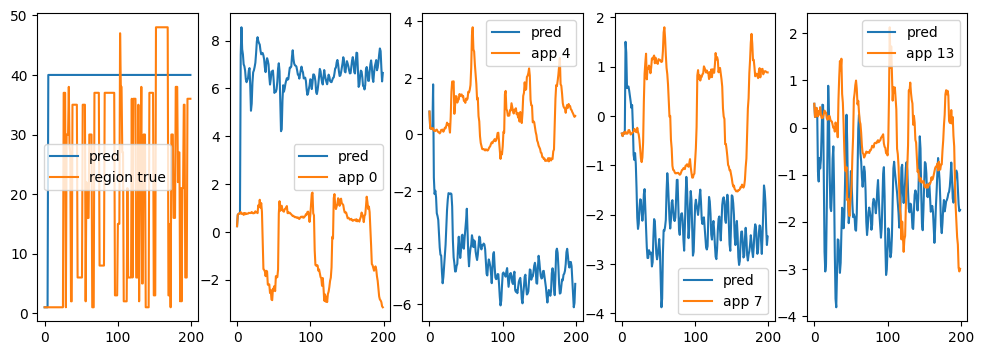

In [152]:
out, pred_appendage = plot_out(model)

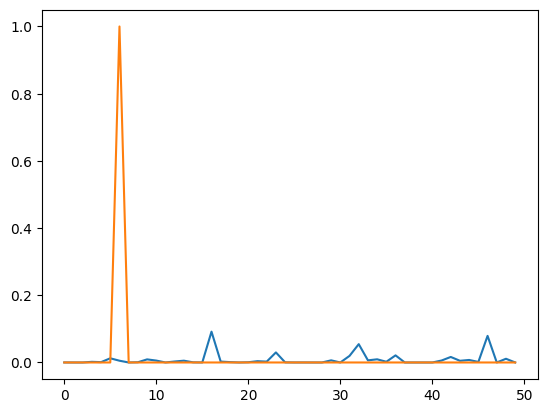

In [157]:
model.eval()

seen_so_far = 50

all_region_tokens = region_tokens.unsqueeze(0).to(torch.int64)

first_region_token = all_region_tokens[:, :seen_so_far]

region_tokens_so_far = list(first_region_token.tolist()[0])

region_token_logits, pred_appendage = model(
    torch.tensor(region_tokens_so_far).unsqueeze(0)
)

region_probs = torch.softmax(region_token_logits.squeeze(0), dim=0)[-1].tolist()
true_region_probs = [0 for i in range(50)]
true_idx = all_region_tokens[:, seen_so_far:seen_so_far+1]
true_region_probs[true_idx] = 1
plt.plot(region_probs)
plt.plot(true_region_probs)

In [ ]:
def inference_appendage(model: torch.nn.Module) -> torch.Tensor:
    region_tokens, appendage_values = appendage_dataset[0]
    print(region_tokens.shape)
    all_region_tokens = region_tokens.unsqueeze(0).to(torch.int64)
    region_token_logits, pred_appendage = model(
        torch.tensor(all_region_tokens)
    )

    region_tokens = torch.argmax(region_token_logits, dim=-1)

    pred_appendage = pred_appendage.squeeze(0).detach()

    return region_tokens, pred_appendage

In [ ]:
plot_out(model)
train(train_appendage=False)
plot_out(model)

In [ ]:
out, pred_appendage = inference(model)

fig, ax = plt.subplots(3, 4, figsize=(15, 8))

ax = ax.flatten()

for i in range(12):

    ax[i].plot(pred_appendage[:900, i], label="pred")
    ax[i].plot(appendage_values[:900, i], label=f"app {i}")
    ax[i].legend()

plt.show()


In [ ]:
plt.plot(out[:900], label="pred")
plt.plot(region_tokens[:900], label="region true")
plt.legend()
plt.show()

In [ ]:
optimizer = AdamW(model.parameters(), lr=base_lr, betas=[0.9, 0.98], eps=1e-9)
scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

In [ ]:
wandb.finish()

In [ ]:
train(train_appendage=False)

In [ ]:
plot_out(model)

In [ ]:
torch.save(model.state_dict(), "big_hand_position_llm.pth")